<a href="https://colab.research.google.com/github/GustavoABrandao/Projeto---IA-Facens/blob/main/Projeto%20Big%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [124]:
# Importando bibliotecas necessárias
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import expr
from pyspark.sql.functions import col, regexp_extract
from pyspark.sql.functions import expr, current_date, year as spark_year
import matplotlib.pyplot as plt
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

spark = SparkSession.builder \
    .appName("PySpark Docker Example") \
    .getOrCreate()

In [125]:
dataframe = spark.read.csv("/content/vehicles.csv", header=True, inferSchema=True)
num_linhas = dataframe.count()
print(f"Número de linhas no DataFrame: {num_linhas}")

Número de linhas no DataFrame: 441802


In [126]:
dataframe.show(50)

+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|        id|                 url|              region|          region_url|price|year|manufacturer|               model|condition|  cylinders| fuel|odometer|title_status|transmission|              VIN|drive|     size|  type|paint_color|           image_url|         description|county|state|    lat|      long|        posting_date|
+----------+--------------------+--------------------+--------------------+-----+----+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----------------+-----+---------+------+-----------+--------------------+--------------------+------+-----+-------+----------+--------------------+
|722

In [127]:
df = dataframe

# Regex mais flexível: ignora o que não for número/ponto/sinal de menos
# Removemos o sinal de negativo de colunas que não podem ser negativas (preço, ano, km)
df = df.withColumn(
    "year",
    expr("try_cast(regexp_replace(year, '[^0-9]', '') as double)")
)

df = df.withColumn(
    "price",
    expr("try_cast(regexp_replace(price, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "odometer",
    expr("try_cast(regexp_replace(odometer, '[^0-9.]', '') as double)")
)

df = df.withColumn(
    "lat",
    expr("try_cast(regexp_replace(lat, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "long",
    expr("try_cast(regexp_replace(long, '[^0-9.-]', '') as double)")
)

df = df.withColumn(
    "car_age",
    spark_year(current_date()) - col("year")
)
# Remoção de colunas
df = df.drop(
    "id", "url", "region_url", "VIN",
    "image_url", "description", "county",
    "posting_date", "size"
)

In [128]:
# =========================
# 2. DROP E FILTROS (MENOS AGRESSIVO)
# =========================

# DICA: Removi lat e long do dropna. Se não tiver localização, a gente mantém o carro!
df = df.dropna(subset=["price", "year", "odometer"])

# Filtros de sanidade
df = df.filter(
    (col("price") >= 100.0) & (col("price") < 1000000.0) &
    (col("year") > 2005.0) & (col("year") <= 2026.0)
)


# VERIFICAÇÃO INTERMEDIÁRIA
contagem = df.count()
print(f"Registros após limpeza inicial: {contagem}")

if contagem > 0:
    # 3. CACHE E ESTATÍSTICA
    df.cache()

    for c in ["price", "odometer"]:
        # Verificamos se há dados suficientes para calcular quantis
        quantis = df.approxQuantile(c, [0.10, 0.90], 0.05)
        if len(quantis) == 2:
            q_low, q_high = quantis[0], quantis[1]
            df = df.filter((col(c) >= q_low) & (col(c) <= q_high))
            print(f"Filtro aplicado em {c}: {q_low} até {q_high}")

    print(f"Registros finais: {df.count()}")
else:
    print("ERRO: O filtro deletou todos os dados! Verifique as colunas de entrada.")
    df.show(5) # Mostra o que restou para você entender o problema

Registros após limpeza inicial: 324278
Filtro aplicado em price: 5000.0 até 35990.0
Filtro aplicado em odometer: 19240.0 até 147000.0
Registros finais: 186660


In [129]:
# =========================
# 3. Colunas categóricas
# =========================

# One-hot (nominais)
categorical_cols = [
    "region", "manufacturer", "fuel", "transmission",
    "drive", "type", "paint_color", "state", "title_status"
]

# StringIndexer (ordinal ou alta cardinalidade)
index_cols = ["condition", "model"]




In [130]:
# =========================
# 4. Criar stages
# =========================
stages = []

# Index + OneHot para categóricas nominais
for col_name in categorical_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    encoder = OneHotEncoder(
        inputCol=col_name + "_index",
        outputCol=col_name + "_onehot",
        dropLast=True
    )

    stages += [indexer, encoder]

# Apenas index para ordinal/alta cardinalidade
for col_name in index_cols:
    indexer = StringIndexer(
        inputCol=col_name,
        outputCol=col_name + "_index",
        handleInvalid="keep"
    )

    stages.append(indexer)



In [131]:
from pyspark.sql.functions import col, udf
from pyspark.sql.types import IntegerType

# ============================================================
# Remover classes específicas de paint_color depois do OneHot
# ============================================================

# Se paint_color_index existir, usa ele diretamente.
# Se não existir, cria uma classe temporária a partir do vetor one-hot.

if "paint_color_index" in df_prepared.columns:

    classes_remover = [6.0, 7.0, 8.0]

    df_prepared = df_prepared.filter(
        ~col("paint_color_index").isin(classes_remover)
    )

else:

    def onehot_to_index(v):
        if v is None:
            return None

        arr = v.toArray()

        if arr.sum() == 0:
            return -1

        return int(arr.argmax())

    onehot_to_index_udf = udf(onehot_to_index, IntegerType())

    df_prepared = df_prepared.withColumn(
        "paint_color_class",
        onehot_to_index_udf(col("paint_color_onehot"))
    )

    classes_remover = [6, 7, 8]

    df_prepared = df_prepared.filter(
        ~col("paint_color_class").isin(classes_remover)
    )

# ============================================================
# Conferir distribuição depois do filtro
# ============================================================

if "paint_color_index" in df_prepared.columns:

    df_prepared.groupBy("paint_color_index") \
        .count() \
        .orderBy("paint_color_index") \
        .show()

else:

    df_prepared.groupBy("paint_color_class") \
        .count() \
        .orderBy("paint_color_class") \
        .show()

# Atualiza a view
df_prepared.createOrReplaceTempView("view_treino_filtrada")

+-----------------+-----+
|paint_color_index|count|
+-----------------+-----+
|              0.0|22981|
|              1.0|20393|
|              2.0|13898|
|              3.0| 9766|
|              4.0| 8727|
|              5.0| 8692|
+-----------------+-----+



In [132]:
# =========================
# 5. Pipeline
# =========================
pipeline = Pipeline(stages=stages)
model = pipeline.fit(df)
df_prepared = model.transform(df)
df_prepared.createOrReplaceTempView("cars_prepared")


In [133]:
features_sql = spark.sql("""
SELECT *
FROM cars_prepared
LIMIT 20
""")

features_sql.show()


+------+-------+------+------------+--------------------+---------+-----------+-----+--------+------------+------------+-----+--------+-----------+-----+---------+----------+-------+------------+-----------------+------------------+-------------------+----------+-------------+------------------+-------------------+-----------+-------------+----------+---------------+-----------------+------------------+-----------+-----------------+------------------+-------------------+---------------+-----------+
|region|  price|  year|manufacturer|               model|condition|  cylinders| fuel|odometer|title_status|transmission|drive|    type|paint_color|state|      lat|      long|car_age|region_index|    region_onehot|manufacturer_index|manufacturer_onehot|fuel_index|  fuel_onehot|transmission_index|transmission_onehot|drive_index| drive_onehot|type_index|    type_onehot|paint_color_index|paint_color_onehot|state_index|     state_onehot|title_status_index|title_status_onehot|condition_index|model

In [134]:
df_pre_treino.count()

89048

In [135]:
df_prepared.createOrReplaceTempView("view_treino")

# Selecionamos as versões para o modelo
df_pre_treino = spark.sql("""
    SELECT
        price,
        car_age,
        odometer,
        lat,
        long,
        region_onehot,
        manufacturer_onehot,
        fuel_onehot,
        transmission_index,
        drive_onehot,
        type_onehot,
        paint_color_onehot,
        state_onehot,
        title_status_onehot,
        condition_index,
        model_index
    FROM view_treino
""")

df_pre_treino.show(50)


+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|  price|car_age|odometer|      lat|      long|    region_onehot|manufacturer_onehot|  fuel_onehot|transmission_index| drive_onehot|    type_onehot|paint_color_onehot|     state_onehot|title_status_onehot|condition_index|model_index|
+-------+-------+--------+---------+----------+-----------------+-------------------+-------------+------------------+-------------+---------------+------------------+-----------------+-------------------+---------------+-----------+
|33590.0|   12.0| 57923.0|    32.59|    -85.48|(404,[333],[1.0])|     (38,[8],[1.0])|(5,[0],[1.0])|               1.0|    (3,[],[])| (13,[2],[1.0])|    (12,[0],[1.0])|(5801,[28],[1.0])|      (6,[0],[1.0])|            0.0|      175.0|
|22590.0|   16.0| 71229.0|    32.59|    -85.48|(404,[333],[1.0])

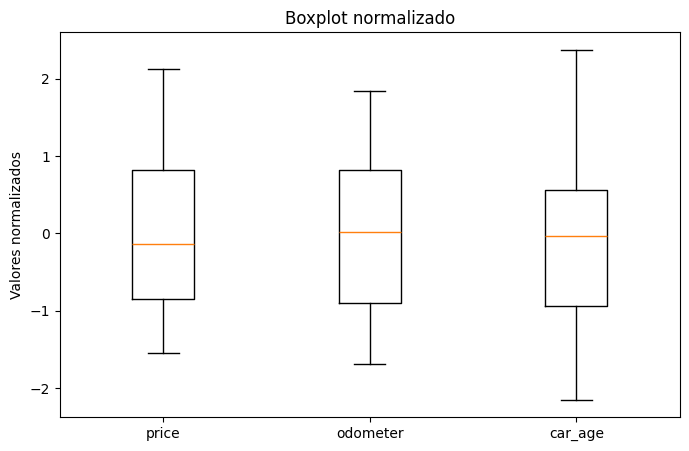

In [136]:
import numpy as np
import matplotlib.pyplot as plt

data_norm = []

cols = ["price", "odometer", "car_age"]

for c in cols:
    sample = df_pre_treino.select(c) \
        .dropna() \
        .sample(False, 0.05, seed=42) \
        .rdd.map(lambda x: x[0]) \
        .collect()

    sample = np.array(sample)

    std = sample.std()

    if std != 0:
        sample = (sample - sample.mean()) / std
    else:
        sample = sample - sample.mean()  # evita divisão por zero

    data_norm.append(sample)

plt.figure(figsize=(8,5))
plt.boxplot(data_norm)
plt.xticks(range(1, len(cols)+1), cols)
plt.title("Boxplot normalizado")
plt.ylabel("Valores normalizados")
plt.show()

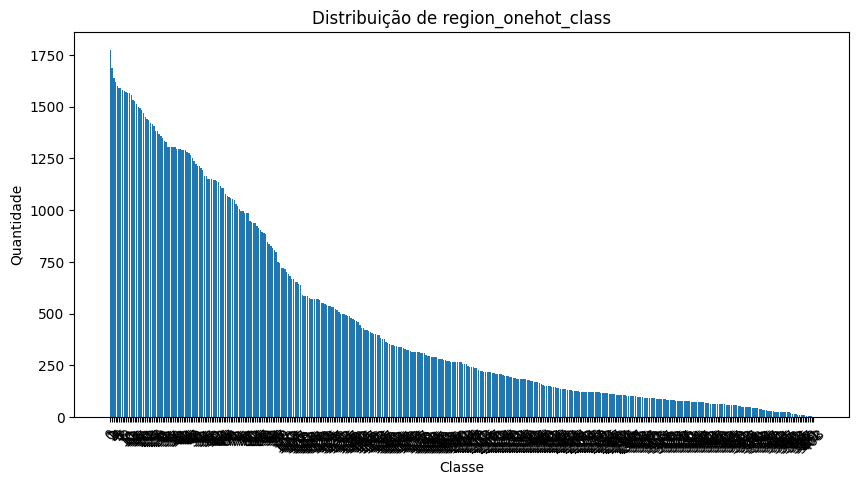

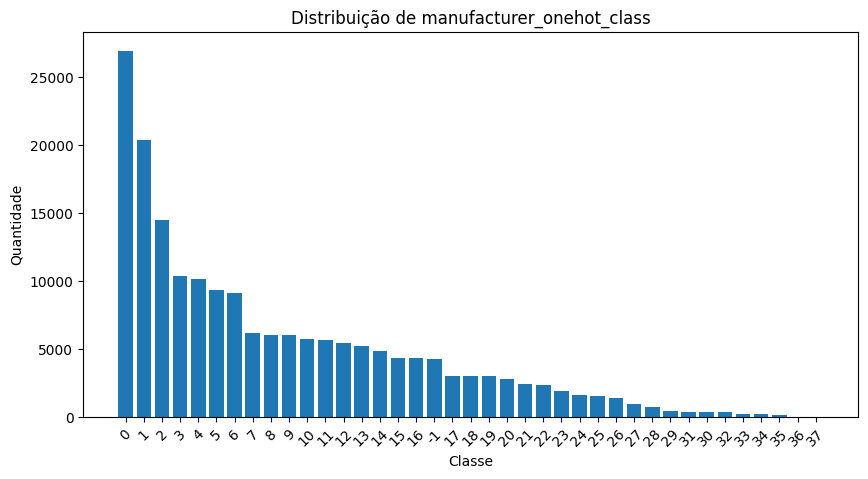

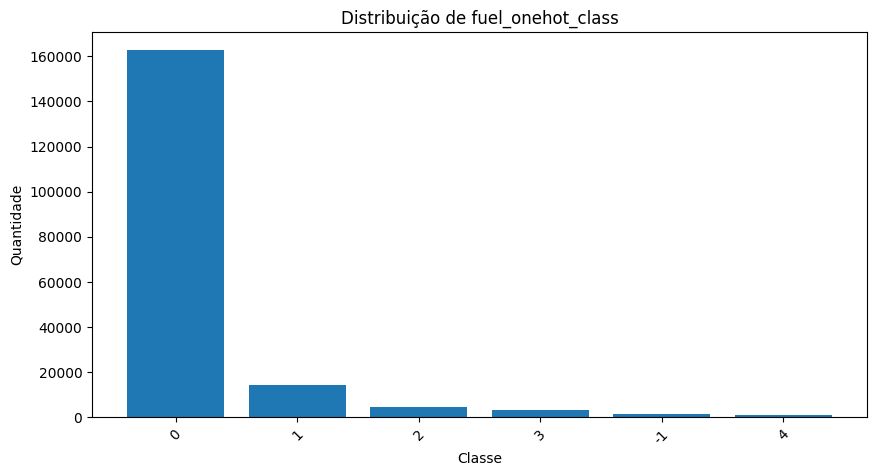

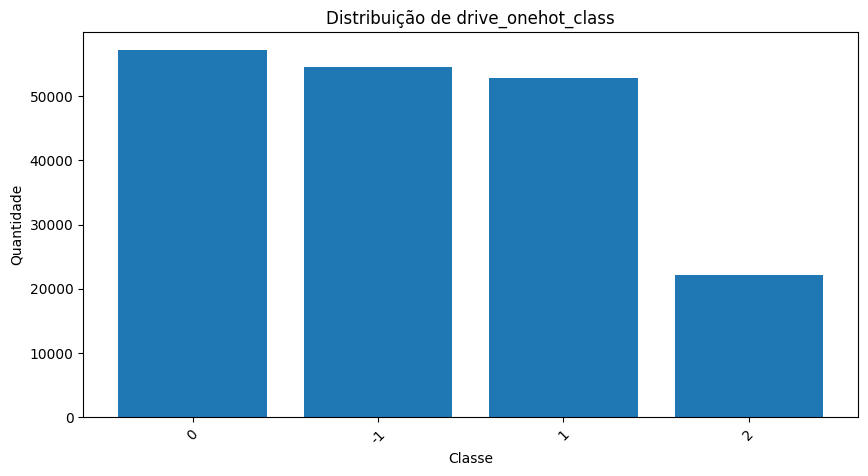

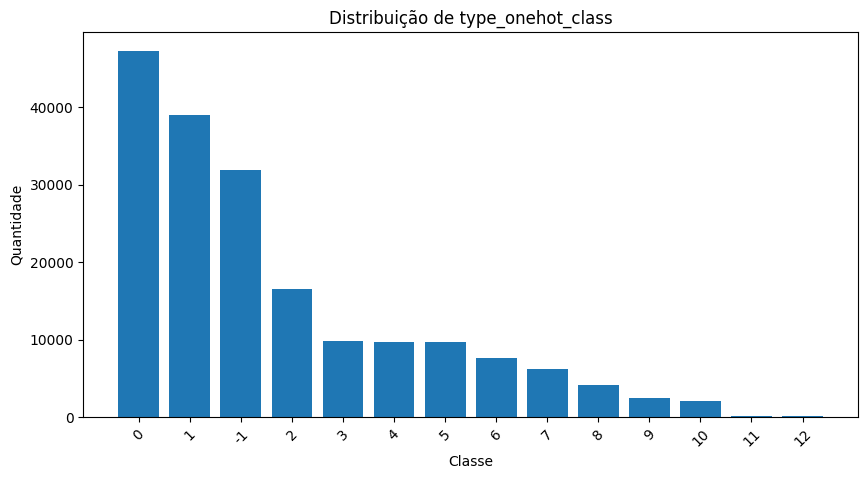

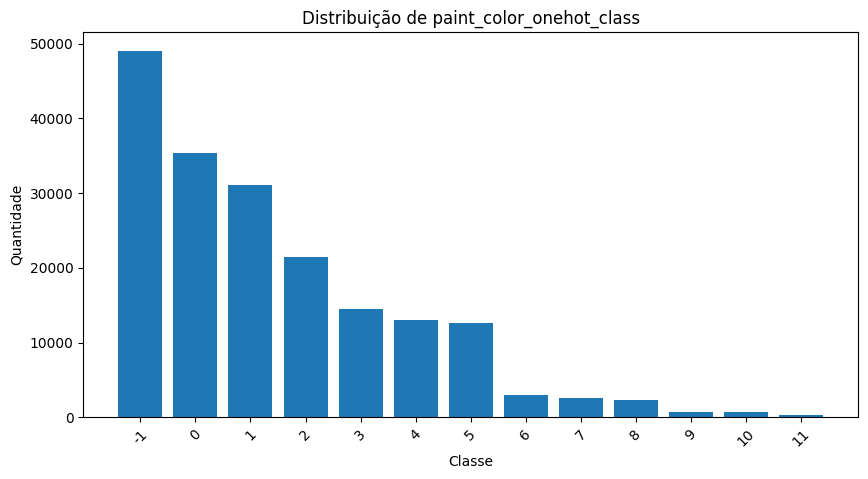

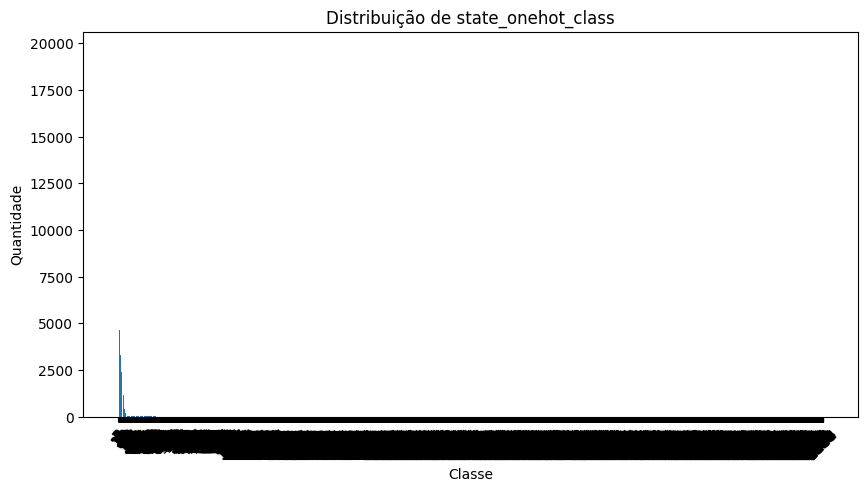

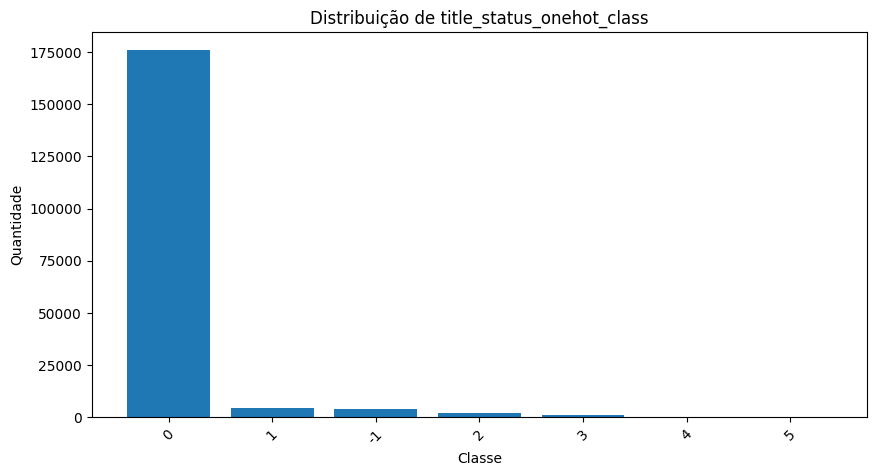

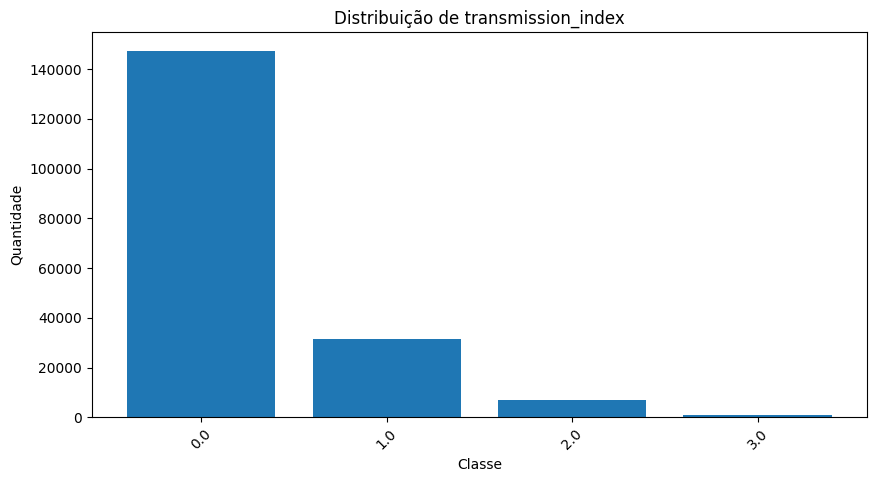

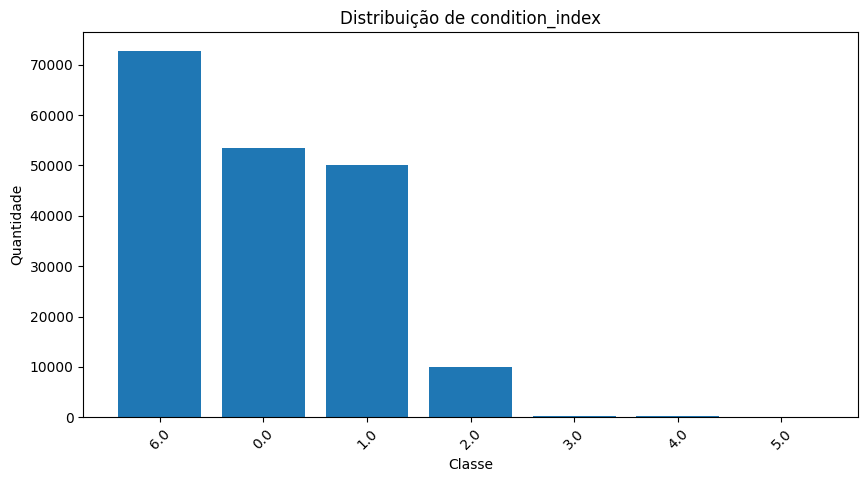

In [ ]:

# Converte vetor one-hot para índice da posição ativa
def onehot_to_index(v):
    if v is None:
        return None
    arr = v.toArray()
    if arr.sum() == 0:
        return -1
    return int(arr.argmax())

onehot_to_index_udf = udf(onehot_to_index, IntegerType())

onehot_cols = [
    "region_onehot",
    "manufacturer_onehot",
    "fuel_onehot",
    "drive_onehot",
    "type_onehot",
    "paint_color_onehot",
    "state_onehot",
    "title_status_onehot"
]

index_cols = [
    "transmission_index",
    "condition_index",
    "model_index"
]

df_plot = df_pre_treino

for c in onehot_cols:
    df_plot = df_plot.withColumn(c + "_class", onehot_to_index_udf(col(c)))

plot_cols = [c + "_class" for c in onehot_cols] + index_cols

for c in plot_cols:
    data = df_plot.groupBy(c) \
        .count() \
        .orderBy("count", ascending=False) \
        .collect()

    x = [str(row[c]) for row in data]
    y = [row["count"] for row in data]

    plt.figure(figsize=(10, 5))
    plt.bar(x, y)
    plt.title(f"Distribuição de {c}")
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
data = df_pre_treino.groupBy("condition_index") \
    .agg({"price": "avg"}) \
    .orderBy("condition_index") \
    .collect()

x = [str(row["condition_index"]) for row in data]
y = [row["avg(price)"] for row in data]

plt.bar(x, y)
plt.title("Preço médio por condição")
plt.show()